### Load libraries

In [10]:
from importlib import reload
from helpers import *
from helpers.leverage import *
from helpers.portfolio import *
from helpers.stats import *
import pandas as pd
from pathlib import Path
from helpers.montecarlo import simulate_parametric, simulate_bootstrap, save_simulations_parquet
from helpers.portfolio import build_portfolios_from_prices
from helpers.leverage import leverage_backtest
import pandas as pd


from helpers.clustering import cluster_select_representatives_from_csv, visualize_clusters
from helpers.fetch import load_data
import pandas as pd

### Clustering

Found 68 tickers across 10 clusters


/Users/giacomomaggiore/Desktop/coding/leverage-api-api/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/giacomomaggiore/Desktop/coding/leverage-api-api/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


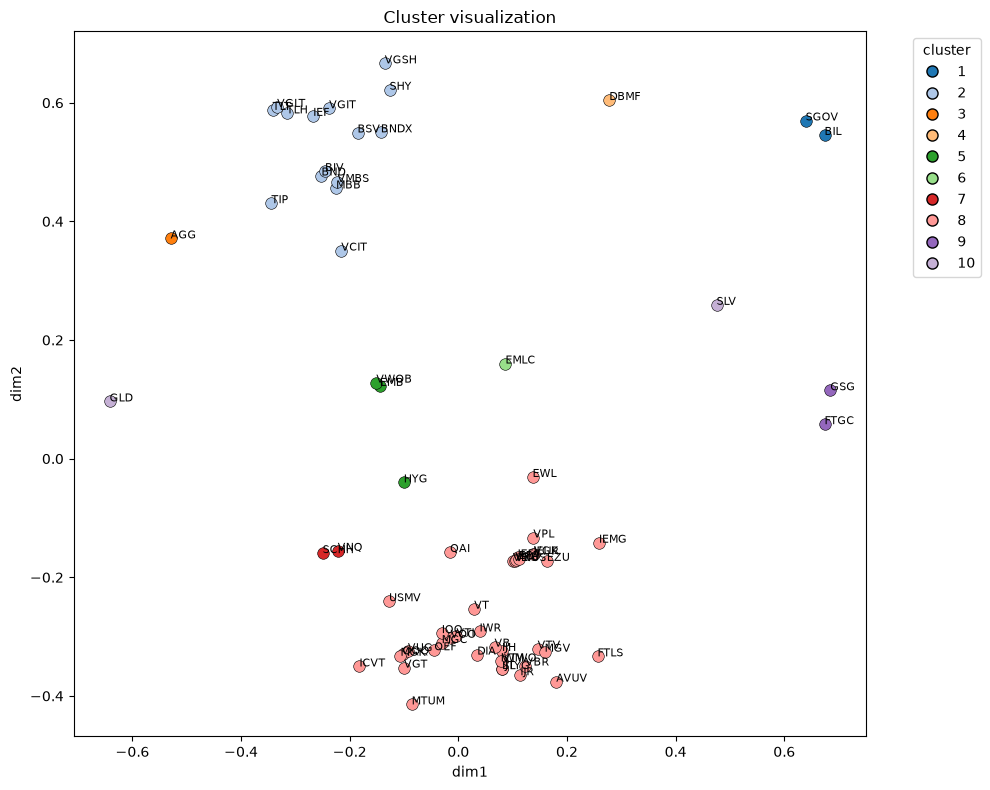

In [11]:
ETF_UNIVERSE_CSV_PATH = "data/etf_universe.csv"

# get clusters (and representatives) from the universe CSV
selected_tickers, clusters = cluster_select_representatives_from_csv(ETF_UNIVERSE_CSV_PATH, n_clusters=10)

print('Found', sum(len(v) for v in clusters.values()), 'tickers across', len(clusters), 'clusters')

# Build aligned price matrix for all tickers in the clusters (inner join on dates)
tickers = sorted([t for members in clusters.values() for t in members])
start_date = '2012-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
prices = pd.concat([load_data(t, start_date, end_date)['adj close'].rename(t) for t in tickers], axis=1, join='inner')
returns = prices.pct_change().dropna()

# Visualize clusters using the returns correlation (MDS embedding)
fig, ax = visualize_clusters(clusters, returns=returns)


### Common window / Optimization / Portfolio construction using the tickers from the clustering

In [12]:
# common window for selected_tickers tickers
min_window, max_window = common_window(selected_tickers)

start_date = "2012-01-01"
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")

print("Min common start date:", min_window, "Max common end date:", max_window)
    
portfolios = build_portfolios(selected_tickers, start_date, end_date)

Min common start date: 2020-06-01 00:00:00 Max common end date: 2026-07-10 00:00:00


### Backtest with historical data using the weights given by optimization 

- min_variance
- equal_weights
- max_sharpie
- market_cap

In [13]:
# Backtest with historical data (min-variance, max-sharpe, market-cap (VT), equal-weight)
from helpers.backtest import backtest_portfolio

# compute portfolio value series for each strategy
min_variance = backtest_portfolio(portfolios["min_variance"], start_value=10_000.0)
max_sharpe  = backtest_portfolio(portfolios["max_sharpe"],  start_value=10_000.0)
market_cap  = backtest_portfolio(portfolios["market_cap"],  start_value=10_000.0)
equal_weight = backtest_portfolio(portfolios["equal_weight"], start_value=10_000.0)

# merge into a single DataFrame for comparison
backtest_results = pd.concat(
    [
        min_variance.rename("min_variance"),
        max_sharpe.rename("max_sharpe"),
        market_cap.rename("market_cap"),
        equal_weight.rename("equal_weight"),
    ],
    axis=1,
)
backtest_results

,min_variance,max_sharpe,market_cap,equal_weight
date,,,,
2020-07-02,10012.773613,10034.437900,10000.0,10027.315265
2020-07-06,10024.487054,10070.079926,10000.0,10069.426850
2020-07-07,10033.116766,10089.181318,10000.0,10040.350536
2020-07-08,10038.464952,10132.814798,10000.0,10075.019611
2020-07-09,10053.642706,10102.292188,10000.0,10056.213941
...,...,...,...,...
2026-07-06,11802.360315,15318.976850,10000.0,16197.859774
2026-07-07,11800.483868,15316.532798,10000.0,16204.919067
2026-07-08,11802.772297,15313.291088,10000.0,16173.169682


### Montecarlo parametric simulation

In [14]:
# Monte Carlo (parametric): simulate returns, rebuild weights, backtest
from helpers.montecarlo import simulate_parametric, rebalance_on_simulation

# simulate ~1 year of daily returns for current tickers
tickers = list(portfolios["min_variance"].columns)
sims_param = simulate_parametric(tickers, n_days=252, n_sims=1, lookback_years=3, seed=42)

# rebuild weights on simulated prices and backtest
W_param, V_param = rebalance_on_simulation(
    sims_param[0], lookback_years=4, freq="BMS", which="min_variance", start_value=10_000.0
)
W_param

,AGG,BND,DBMF,EMLC,GLD,GSG,HYG,SGOV,VNQ,VOO,VT
2000-02-01,0.11903,0.13746,0.17518,0.15784,0.02515,0.03017,0.09614,0.25454,0.0,0.0,0.00449
2000-02-02,0.11903,0.13746,0.17518,0.15784,0.02515,0.03017,0.09614,0.25454,0.0,0.0,0.00449
2000-02-03,0.11903,0.13746,0.17518,0.15784,0.02515,0.03017,0.09614,0.25454,0.0,0.0,0.00449
2000-02-04,0.11903,0.13746,0.17518,0.15784,0.02515,0.03017,0.09614,0.25454,0.0,0.0,0.00449
2000-02-07,0.11903,0.13746,0.17518,0.15784,0.02515,0.03017,0.09614,0.25454,0.0,0.0,0.00449
...,...,...,...,...,...,...,...,...,...,...,...
2000-12-13,0.05630,0.05730,0.04558,0.02578,0.00429,0.00936,0.02275,0.77865,0.0,0.0,0.00000
2000-12-14,0.05630,0.05730,0.04558,0.02578,0.00429,0.00936,0.02275,0.77865,0.0,0.0,0.00000
2000-12-15,0.05630,0.05730,0.04558,0.02578,0.00429,0.00936,0.02275,0.77865,0.0,0.0,0.00000
2000-12-18,0.05630,0.05730,0.04558,0.02578,0.00429,0.00936,0.02275,0.77865,0.0,0.0,0.00000


## Montecarlo Bootstrap

In [15]:
# Monte Carlo (bootstrap): moving-block bootstrap, rebuild weights, backtest
from helpers.montecarlo import simulate_bootstrap, rebalance_on_simulation

sims_boot = simulate_bootstrap(
    tickers, n_days=252, n_sims=3, lookback_years=3, block_size=10, seed=1
)
W_boot, V_boot = rebalance_on_simulation(
    sims_boot[0], lookback_years=4, freq="BMS", which="min_variance", start_value=10_000.0
)

W_boot

,AGG,BND,DBMF,EMLC,GLD,GSG,HYG,SGOV,VNQ,VOO,VT
2000-02-01,0.08287,0.13272,0.10155,0.0,0.0,0.07621,0.18144,0.42522,0.0,0.0,0.0
2000-02-02,0.08287,0.13272,0.10155,0.0,0.0,0.07621,0.18144,0.42522,0.0,0.0,0.0
2000-02-03,0.08287,0.13272,0.10155,0.0,0.0,0.07621,0.18144,0.42522,0.0,0.0,0.0
2000-02-04,0.08287,0.13272,0.10155,0.0,0.0,0.07621,0.18144,0.42522,0.0,0.0,0.0
2000-02-07,0.08287,0.13272,0.10155,0.0,0.0,0.07621,0.18144,0.42522,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2000-12-13,0.02326,0.08331,0.03933,0.0,0.0,0.01017,0.07508,0.76885,0.0,0.0,0.0
2000-12-14,0.02326,0.08331,0.03933,0.0,0.0,0.01017,0.07508,0.76885,0.0,0.0,0.0
2000-12-15,0.02326,0.08331,0.03933,0.0,0.0,0.01017,0.07508,0.76885,0.0,0.0,0.0
2000-12-18,0.02326,0.08331,0.03933,0.0,0.0,0.01017,0.07508,0.76885,0.0,0.0,0.0


## Montecarlo aggregation and exporting

In [16]:
from pathlib import Path
from helpers.montecarlo import simulate_and_backtest_portfolios, save_simulations_parquet

# use a local writable path
out_path = Path("output/mc_values.parquet")

df = simulate_and_backtest_portfolios(
    tickers=selected_tickers,
    n_days=252*10,
    n_sims=2,
    lookback_years=3,
    block_size=10,
    seed=1,
    method="bootstrap",
)
save_simulations_parquet(df, str(out_path), engine="pyarrow")



In [27]:
# Load saved simulation values and prepare convenience slices

df_loaded = pd.read_parquet(out_path, engine="pyarrow")

df_loaded.head()

# Convenience: pick one strategy across all sims
df = df_loaded.xs("min_variance", level="strategy", axis=1)

### Montecarlo analysis



In [19]:
summary = quantiles_df(df)
summary

q01     16098.957504
q10     16122.992860
q25     16163.051785
q50     16229.816660
q75     16296.581535
q90     16336.640461
q99     16360.675816
mean    16229.816660
min     16096.286909
max     16363.346411
std       188.839584
dtype: float64

In [25]:
# Examples of slicing the simulations DataFrame

# If the 'sim' level is still string-typed, convert to int for numeric indexing
if isinstance(df_loaded.columns, pd.MultiIndex):
    if df_loaded.columns.levels[0].dtype == object:
        try:
            df_loaded.columns = pd.MultiIndex.from_tuples(
                [(int(sim), strat) for sim, strat in df_loaded.columns], names=df_loaded.columns.names
            )
        except Exception:
            pass

# single column (one sim, one strategy) -> Series of portfolio value over time
df_loaded[(1, "min_variance")]

# same, via .loc
df_loaded.loc[:, (1, "min_variance")]

# all strategies for one sim -> sub-DataFrame, columns become just "strategy"
df_loaded[1]                       # or df_loaded.xs(1, level="sim", axis=1)

# one strategy across all sims -> sub-DataFrame, columns become just "sim"
df_loaded.xs("min_variance", level="strategy", axis=1)

# the full "horizon" (all dates) for one sim/strategy path is just the Series itself
# df_loaded[(1, "min_variance")].plot()

# slice a date range on any of the above
df_loaded.loc["2000-06-01":"2000-09-01", (1, "min_variance")]

date
2000-06-01    10509.342029
2000-06-02    10508.244732
2000-06-05    10525.015617
2000-06-06    10526.869076
2000-06-07    10534.256930
                  ...     
2000-08-28    10700.406898
2000-08-29    10703.236737
2000-08-30    10712.587109
2000-08-31    10715.984133
2000-09-01    10708.977641
Name: (1, min_variance), Length: 67, dtype: float64

### Margin Investing - Leverage


In [22]:
# apply leverage investing to selected portfgolio

portfolio = build_portfolios(selected_tickers, start_date, end_date)

min_variance_weights = portfolio["min_variance"]
max_sharpe_weights  = portfolio["max_sharpe"]
equal_weight_weights = portfolio["equal_weight"]
market_cap_weights  = portfolio["market_cap"]


leverage_backtest_result = leverage_backtest(
    weights = min_variance_weights,
    leverage = 2,
    start_value = 10_000.0,
    band = 0.05,
    spread = 0.01,
)

In [30]:
# Monte Carlo with leveraged backtests for all strategies, saving results to Parquet

# --- Configuration ---
method = "bootstrap"          # "bootstrap" | "parametric"
n_days = 252 * 5               # simulation horizon (trading days)
n_sims = 5                     # number of simulations
lookback_years = 3             # lookback for (re)optimizing weights on each path
start_value = 10_000.0

# Leverage parameters
leverage = 2.0                 # target gross exposure / equity
lev_rebalance_freq = "monthly" # leverage rebalance schedule: "daily" | "weekly" | "monthly"
band = 0.05                    # drift band (used only if lev_rebalance_freq is None)
hard_cap = 4.0                 # forced rebalance if leverage exceeds this
spread = 0.01                  # EFFR + spread borrowing cost approximation

# Simulation settings
seed = 1
block_size = 10                # used only for bootstrap

# Output path
out_path = Path("output/mc_leverage_values.parquet")

# Ensure VT is available for the market_cap strategy
base_tickers = list(dict.fromkeys(selected_tickers))
sim_tickers = base_tickers.copy()
if "VT" not in sim_tickers:
    sim_tickers.append("VT")

# --- Run simulations ---
if method == "bootstrap":
    simulations = simulate_bootstrap(
        sim_tickers,
        n_days=n_days,
        n_sims=n_sims,
        lookback_years=lookback_years,
        block_size=block_size,
        seed=seed,
    )
elif method == "parametric":
    simulations = simulate_parametric(
        sim_tickers,
        n_days=n_days,
        n_sims=n_sims,
        lookback_years=lookback_years,
        seed=seed,
    )
else:
    raise ValueError("method must be 'bootstrap' or 'parametric'")

# --- Build weights and run leveraged backtests on each simulation ---

strategies = ["min_variance", "max_sharpe", "market_cap", "equal_weight"]
all_values = []  # list[pd.Series] with MultiIndex name (sim, strategy)

for i, sim in enumerate(simulations, start=1):
    # Business-day index for calendar-aware rebalancing
    idx = pd.bdate_range(start=pd.Timestamp("2000-01-03"), periods=sim.shape[0])
    effr = sim["EFFR"].copy() if "EFFR" in sim.columns else None
    if effr is not None:
        effr.index = idx
    rets = sim.drop(columns=["EFFR"], errors="ignore").copy()
    rets.index = idx

    # Use the simulated tickers (including VT) to support market_cap
    prices = (1.0 + rets[sim_tickers]).cumprod()

    # Compute dynamic portfolios on the simulated prices
    weights = build_portfolios_from_prices(
        prices=prices,
        start=prices.index.min(),
        end=prices.index.max(),
        lookback_years=lookback_years,
        freq="BMS",  # rebalance portfolio weights monthly (business-month start)
    )

    # Apply leveraged backtest for each strategy
    for strategy in strategies:
        W = weights[strategy]
        lev_df = leverage_backtest(
            W,
            leverage=leverage,
            start_value=start_value,
            returns=rets,
            effr=effr,
            freq=lev_rebalance_freq,  # leverage rebalancing schedule
            band=band,
            hard_cap=hard_cap,
            spread=spread,
        )
        s = lev_df["portfolio_value"].rename((i, strategy))
        all_values.append(s)

# Aggregate into a single DataFrame with MultiIndex columns (sim, strategy)
values_df = pd.concat(all_values, axis=1)
values_df.columns = pd.MultiIndex.from_tuples(values_df.columns, names=["sim", "strategy"])
values_df.index.name = "date"

# Save to Parquet
save_simulations_parquet(values_df, str(out_path), engine="pyarrow")

values_df.head()

sim                   1                                                   2  \
strategy   min_variance   max_sharpe   market_cap equal_weight min_variance   
date                                                                          
2000-01-03  9998.380556  9998.380556  9998.380556  9998.380556  9998.241667   
2000-01-04  9996.761373  9996.761373  9996.761373  9996.761373  9996.483643   
2000-01-05  9995.141929  9995.141929  9995.141929  9995.141929  9994.725309   
2000-01-06  9993.522222  9993.522222  9993.522222  9993.522222  9992.966667   
2000-01-07  9991.902253  9991.902253  9991.902253  9991.902253  9991.207715   

sim                                                          3               \
strategy     max_sharpe   market_cap equal_weight min_variance   max_sharpe   
date                                                                          
2000-01-03  9998.241667  9998.241667  9998.241667  9998.241667  9998.241667   
2000-01-04  9996.483643  9996.483643  9996.483643  9996.483643  9996.483643   
2000-01-05  9994.725309  9994.725309  9994.725309  9994.725309  9994.725309   
2000-01-06  9992.966667  9992.966667  9992.966667  9992.966667  9992.966667   
2000-01-07  9991.207715  9991.207715  9991.207715  9991.207715  9991.207715   

sim                                             4                            \
strategy     market_cap equal_weight min_variance   max_sharpe   market_cap   
date                                                                          
2000-01-03  9998.241667  9998.241667  9998.241667  9998.241667  9998.241667   
2000-01-04  9996.483643  9996.483643  9996.483643  9996.483643  9996.483643   
2000-01-05  9994.725309  9994.725309  9994.725309  9994.725309  9994.725309   
2000-01-06  9992.966667  9992.966667  9992.966667  9992.966667  9992.966667   
2000-01-07  9991.207715  9991.207715  9991.207715  9991.207715  9991.207715   

sim                                5                                         
strategy   equal_weight min_variance   max_sharpe   market_cap equal_weight  
date                                                                         
2000-01-03  9998.241667  9998.241667  9998.241667  9998.241667  9998.241667  
2000-01-04  9996.483643  9996.483643  9996.483643  9996.483643  9996.483643  
2000-01-05  9994.725309  9994.725309  9994.725309  9994.725309  9994.725309  
2000-01-06  9992.966667  9992.966667  9992.966667  9992.966667  9992.966667  
2000-01-07  9991.207715  9991.207715  9991.207715  9991.207715  9991.207715

In [31]:
# Import simulation df and compute quantiles per strategy

sims = pd.read_parquet(out_path, engine="pyarrow")

# Normalize 'sim' level to int for easier slicing
if isinstance(sims.columns, pd.MultiIndex):
    try:
        sims.columns = pd.MultiIndex.from_tuples(
            [(int(sim), strat) for sim, strat in sims.columns], names=sims.columns.names
        )
    except Exception:
        pass

min_variance_sims = sims.xs("min_variance", level="strategy", axis=1)
max_sharpe_sims   = sims.xs("max_sharpe",   level="strategy", axis=1)
market_cap_sims   = sims.xs("market_cap",   level="strategy", axis=1)
equal_weight_sims = sims.xs("equal_weight", level="strategy", axis=1)

quantiles = quantiles_df(min_variance_sims)
quantiles

q01     12745.109695
q10     12885.276631
q25     13118.888190
q50     13362.922927
q75     13374.723262
q90     13543.111293
q99     13644.144112
mean    13248.287990
min     12729.535591
max     13655.369980
std       346.659470
dtype: float64

[Docs](https://pyportfolioopt.readthedocs.io/en/stable/index.html)